# EDA и тематическое моделирование

Ноутбук показывает разведывательный анализ, тематическое моделирование и работу с признаками по техническому заданию

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

DATA_PATH = Path('data/raw/datasets.csv')
ANALYSIS_PATH = Path('results/text_analysis.json')
FIGURES_DIR = Path('results/figures')

data = pd.read_csv(DATA_PATH)
analysis = json.loads(ANALYSIS_PATH.read_text(encoding='utf-8'))
print('строк:', len(data))
print('колонки:', data.columns.tolist())
data.head()

строк: 210989
колонки: ['Unnamed: 0', 'text', 'sentiment']


,Unnamed: 0,text,sentiment
0,43956,Развода на деньги нет\nНаблюдаюсь в Лайфклиник...,1
1,17755,Отель выбрали потому что рядом со стадионом. О...,0
2,20269,"Вылечили\nГноился с рождения глазик, в поликли...",1
3,16648,Хорошее расположение.С вокзала дошли пешком.Но...,0
4,27879,"Отличное месторасположение,прекрасный вид,особ...",1


## EDA: распределение классов

,количество
NEUTRAL,54887
POSITIVE,100792
NEGATIVE,55310


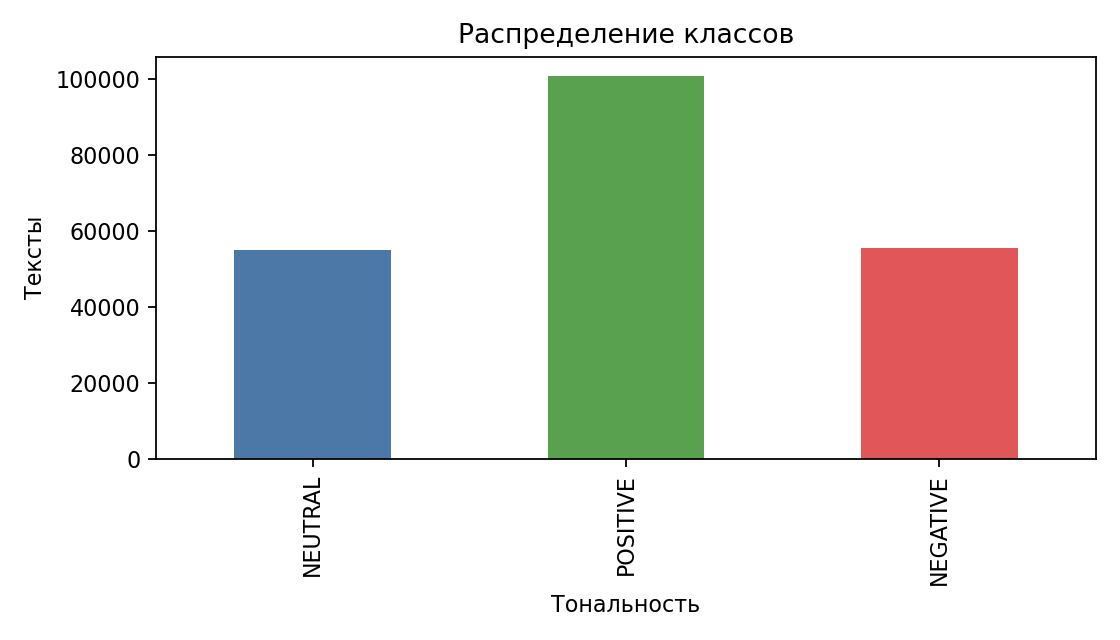

In [2]:
class_distribution = pd.Series(analysis['eda']['class_distribution'], name='количество')
display(class_distribution.to_frame())
display(Image(filename=str(FIGURES_DIR / 'class_distribution.png')))

## EDA: текстовые признаки

,char_len,word_count,avg_word_len,exclamation_count,question_count,digit_count,uppercase_ratio
NEUTRAL,965.7896,143.1301,6.6595,0.9906,0.6879,9.4463,0.0221
POSITIVE,746.8349,110.5781,6.8999,1.6172,0.5433,5.3055,0.0264
NEGATIVE,747.4281,117.0128,6.3729,2.0723,0.7521,5.4377,0.0282


дубли: 10539
пустые после очистки: 3


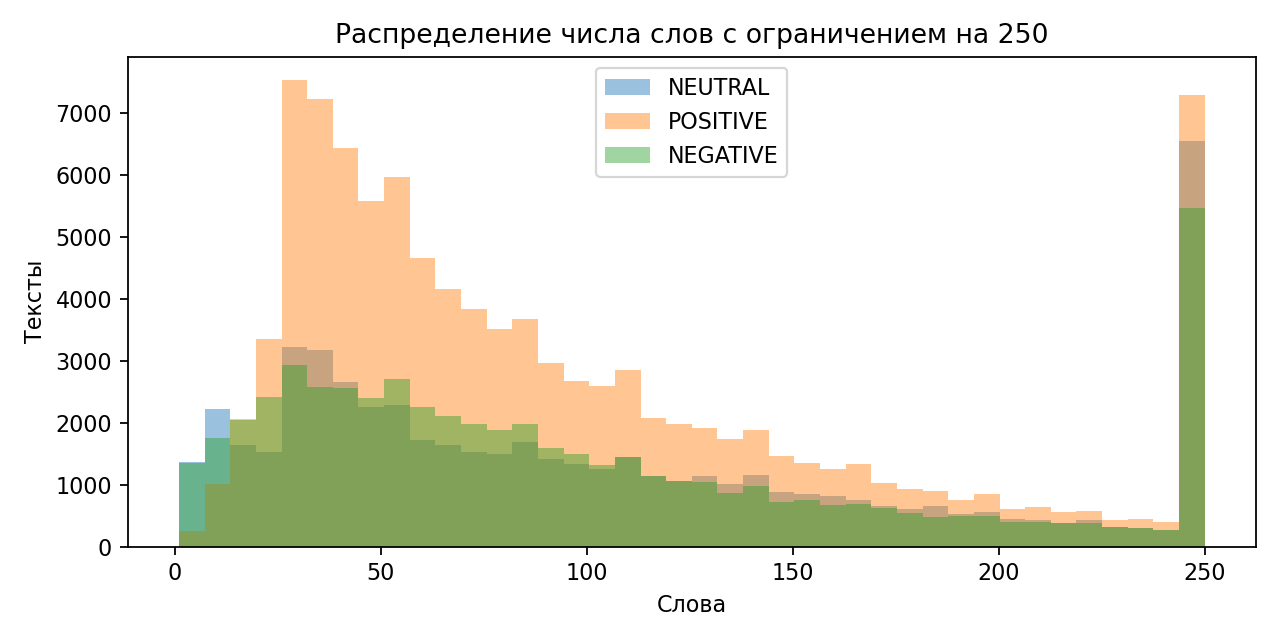

In [3]:
features_by_class = pd.DataFrame(analysis['eda']['features_by_class']).T
display(features_by_class)
print('дубли:', analysis['eda']['duplicates'])
print('пустые после очистки:', analysis['eda']['empty_after_clean'])
display(Image(filename=str(FIGURES_DIR / 'text_length_distribution.png')))

## Выбор алгоритма тематического моделирования

Выбран NMF поверх TF-IDF: он интерпретируем, хорошо работает с разреженными n-граммами и стабильнее для отзывов, чем LDA на сырых счетчиках

In [4]:
topics = analysis['topic_modeling']['topics']
topics_table = pd.DataFrame({
    'тема': [topic['topic_id'] for topic in topics],
    'ключевые_слова': [', '.join(topic['top_words']) for topic in topics],
    'вес_темы': [topic['weight'] for topic in topics],
})
display(topics_table)

,тема,ключевые_слова,вес_темы
0,0,"просто, можно, будет, вообще, тут, про, больше...",262.859461
1,1,"отель, номера, персонал, рядом, метро, располо...",288.859598
2,2,"спасибо, огромное, огромное спасибо, большое, ...",205.992853
3,3,"обслуживание, ресторан, кухня, понравилось, вк...",252.635094
4,4,"года, тенге, ао, году, казахстана, рк, казахст...",133.554758
5,5,"врач, меня, врача, после, прием, врачи, узи, р...",228.790468
6,6,"благодарность, хочу, выразить, хочу выразить, ...",157.406940
7,7,"номер, номере, отеле, отеля, завтрак, день, от...",242.078843


## Визуализация тем

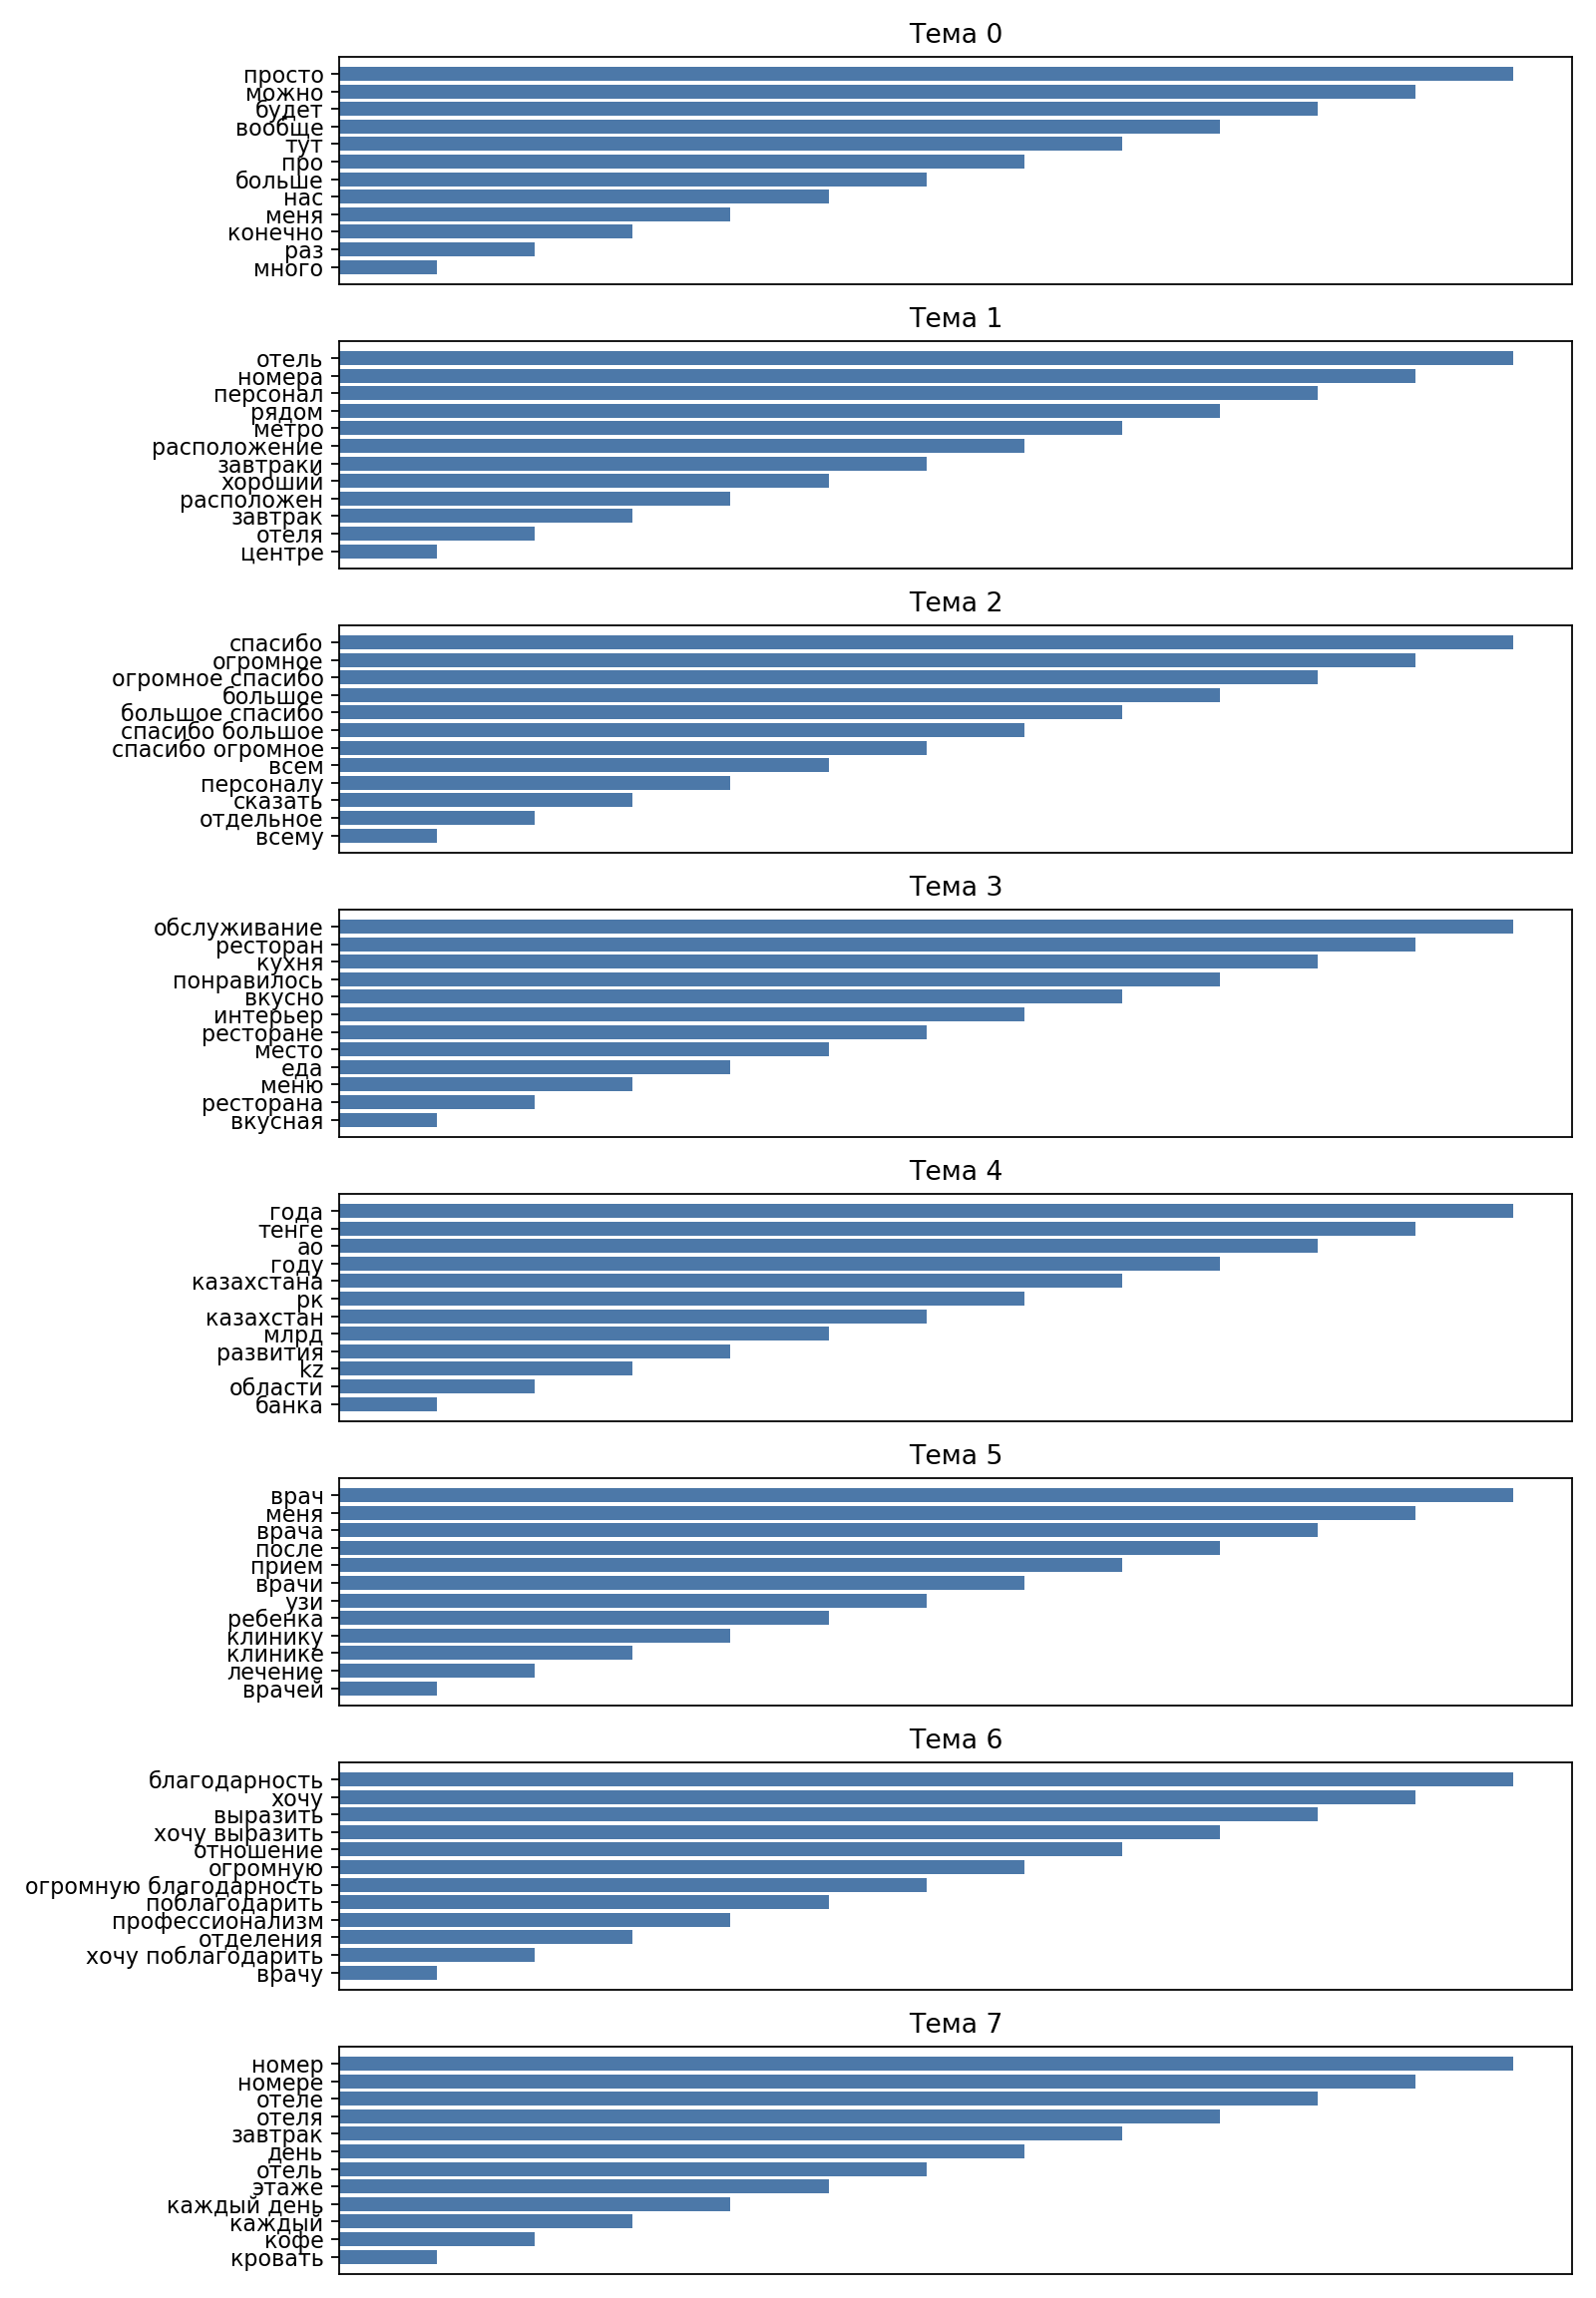

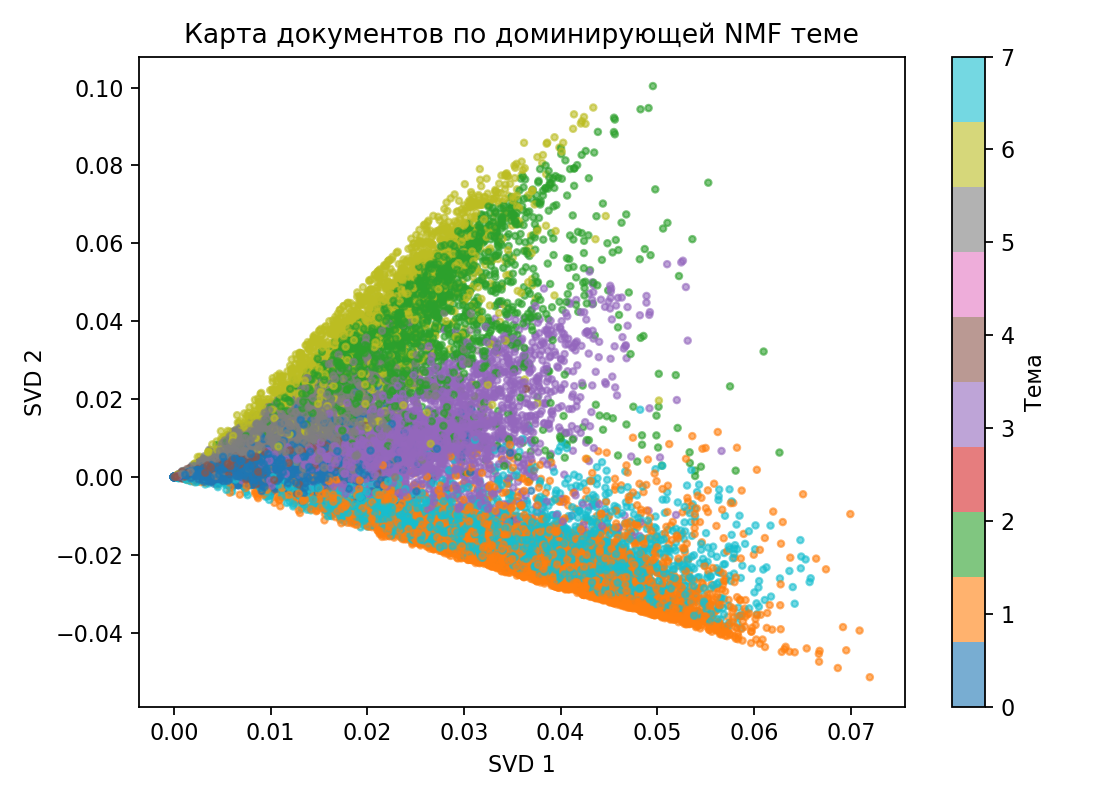

In [5]:
display(Image(filename=str(FIGURES_DIR / 'topic_words.png')))
display(Image(filename=str(FIGURES_DIR / 'topic_scatter.png')))

## Конструирование и отбор признаков

In [6]:
baseline = analysis['feature_engineering_selection_baseline']
print('размеры частей:', baseline['split_sizes'])
print('TF-IDF признаков:', baseline['tfidf_features'])
print('отобранных TF-IDF признаков:', baseline['selected_tfidf_features'])
print('ручных признаков:', baseline['manual_features'])
print('ключевые отобранные признаки:')
print(', '.join(baseline['top_selected_features'][:30]))

main_metric = pd.Series({'Macro F1': baseline['test']['f1_macro']})
display(main_metric.to_frame('значение'))

размеры частей: {'train': 23999, 'val': 3000, 'test': 3000}
TF-IDF признаков: 30000
отобранных TF-IDF признаков: 12000
ручных признаков: 7
ключевые отобранные признаки:
благодарность, спасибо, отель, врач, огромное, врача, хочу, номера, завтрак, сказали, поблагодарить, дозвониться, прием, огромное спасибо, выразить, сказала, хочу поблагодарить, номер, метро, профессионализм, номере, хочу выразить, деньги, трубку, большое, регистратуре, ужас, отеле, завтраки, довольна


,значение
Macro F1,0.691157


## Варианты улучшения тематического моделирования

- Лемматизация через pymorphy3 или natasha
- Подбор числа тем по coherence score
- Расширенный доменный список stop words
- Отдельное моделирование тем внутри каждого класса тональности
- BERTopic или Top2Vec на эмбеддингах предложений
- Удаление дублей и слишком коротких текстов перед моделированием